In [1]:
import networkx as nx
import pandas as pd
from src.utils.data_loader import ROOT

# Caminho do grafo salvo anteriormente
GRAPH_PATH = ROOT / "artifacts/graph/network_disparity.graphml"
#OUTPUT_CSV = ROOT / "reports/graph_analysis/centralidade_subreddits.csv"

In [2]:
print('='*50)
print(f"Carregando o grafo de:\n{GRAPH_PATH}")

try:
    G = nx.read_graphml(GRAPH_PATH)
except FileNotFoundError:
    print("Erro: Arquivo .graphml não encontrado. Verifique o caminho.")

print(f"Grafo carregado: {G.number_of_nodes()} nós e {G.number_of_edges()} arestas.")

Carregando o grafo de:
/home/mateus/reddit/artifacts/graph/network_disparity.graphml
Grafo carregado: 4873 nós e 11961 arestas.


In [3]:
print("\nCalculando métricas de centralidade (isso pode levar alguns instantes)...")

# Centralidade de Grau (Subreddits com mais conexões diretas)
degree_cent = nx.degree_centrality(G)

# Centralidade de Proximidade (Subreddits mais 'perto' de todos os outros)
closeness_cent = nx.closeness_centrality(G)

# Centralidade de Intermediação (Pontes entre comunidades diferentes)
# Se o grafo for muito grande, você pode usar o parâmetro 'k' para aproximar, ex: k=100
betweenness_cent = nx.betweenness_centrality(G, weight='peso_jaccard')


Calculando métricas de centralidade (isso pode levar alguns instantes)...


In [4]:
eigen_cent = nx.eigenvector_centrality(G, weight='peso_jaccard', max_iter=1000)

In [5]:
print("Estruturando os dados de análise...")
dados_centralidade = []

for node in G.nodes():
    dados_centralidade.append({
        "subreddit": node,
        # Recupera a comunidade que salvamos no passo anterior (caso exista)
        "comunidade_louvain": G.nodes[node].get("louvain_community", "Não mapeada"),
        "centralidade_grau": degree_cent[node],
        "centralidade_proximidade": closeness_cent[node],
        "centralidade_intermediacao": betweenness_cent[node],
        "centralidade_autovetor": eigen_cent[node],
        "grau_absoluto": G.degree(node)
    })
    
df = pd.DataFrame(dados_centralidade)

# Ordena pelos subreddits mais centrais (usando grau como critério principal)
df = df.sort_values(by="centralidade_autovetor", ascending=False).reset_index(drop=True)

# 3. Exibir o Top 10 Hubs no terminal
print("\n--- TOP 10 SUBREDDITS MAIS CENTRAIS (POR GRAU) ---")
display(df.head(10))

Estruturando os dados de análise...

--- TOP 10 SUBREDDITS MAIS CENTRAIS (POR GRAU) ---


,subreddit,comunidade_louvain,centralidade_grau,centralidade_proximidade,centralidade_intermediacao,centralidade_autovetor,grau_absoluto
0,whitepeoplegifs,47,0.015599,0.131168,0.000020,0.249762,76
1,blackpeoplegifs,47,0.015805,0.131901,0.000682,0.233441,77
2,wholesomegifs,47,0.022578,0.132722,0.001575,0.231308,110
3,youseeingthisshit,47,0.026273,0.132779,0.004020,0.208072,128
4,instant_regret,47,0.020936,0.133815,0.001139,0.201940,102
5,gifsthatkeepongiving,47,0.021552,0.135530,0.005009,0.189143,105
6,eyebleach,47,0.017857,0.129897,0.000687,0.177997,87
7,nonononoyes,47,0.019910,0.130338,0.002027,0.167840,97
8,educationalgifs,47,0.016215,0.129752,0.000692,0.161571,79
9,thisismylifenow,47,0.011700,0.124308,0.000024,0.155151,57


In [32]:
# 1. Conta o número total de comunidades únicas
total_comunidades = df["comunidade_louvain"].nunique()

print("="*50)
print(f"O algoritmo de Louvain detectou: {total_comunidades} comunidades.")
print("="*50)

# 2. Mostra a distribuição de subreddits por comunidade (do maior para o menor)
print("\nQuantidade de subreddits em cada comunidade:")
print(df["comunidade_louvain"].value_counts())
print("="*50)

O algoritmo de Louvain detectou: 479 comunidades.

Quantidade de subreddits em cada comunidade:
comunidade_louvain
47     443
401    413
153    344
1      306
67     273
      ... 
236      2
6        2
241      2
278      2
64       2
Name: count, Length: 479, dtype: int64


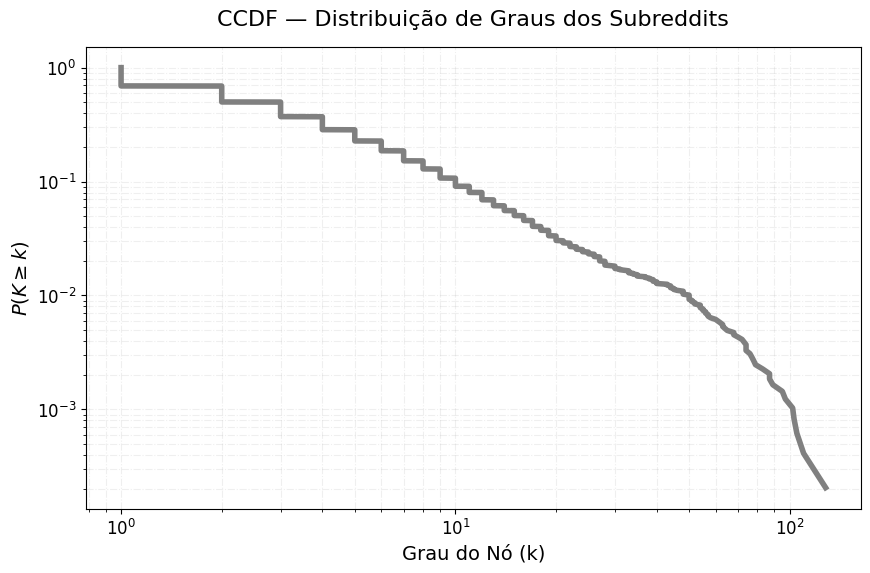

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# --- 1. Extrair os graus dos nós do seu grafo G ---
# dict(G.degree()).values() extrai o grau absoluto de cada nó
graus = list(dict(G.degree()).values())

# --- 2. Preparando os dados para a CCDF ---
sorted_graus = np.sort(graus)
n = len(sorted_graus)

# P(X >= x)
# Usamos (np.arange(n) / n) invertendo a lógica ou 1.0 - (np.arange(1, n + 1) / n)
# Uma forma segura para garantir que o maior valor não zere na escala log:
ccdf = 1.0 - (np.arange(n) / n)

# --- 3. Plotagem Gráfica ---
plt.figure(figsize=(10, 6), facecolor='white')

# Plotando a curva
plt.plot(sorted_graus, ccdf, linewidth=4, color='gray', label='Grau dos Nós')

# --- O PULO DO GATO: Escala Log-Log ---
# Redes complexas exigem escala logarítmica para evidenciar leis de potência
plt.xscale('log')
plt.yscale('log')

# Formatação dos eixos e títulos
plt.xlabel("Grau do Nó (k)", fontsize=14)
plt.ylabel(r"$P(K \geq k)$", fontsize=14)
plt.title("CCDF — Distribuição de Graus dos Subreddits", fontsize=16, pad=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Grid especial para escalas logarítmicas
plt.grid(True, which="both", linestyle="-.", alpha=0.2)

plt.show()

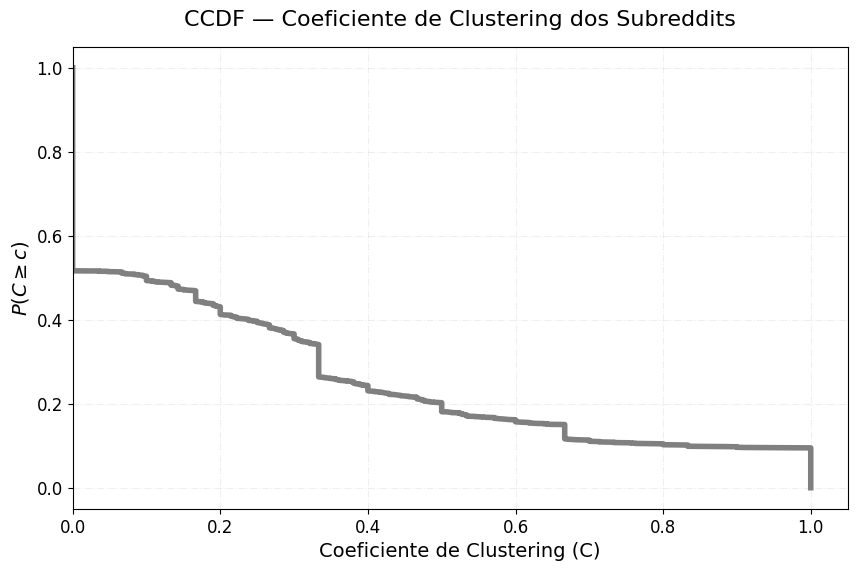

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# --- 1. Calcular o Coeficiente de Clustering de cada nó ---
# nx.clustering(G) retorna um dicionário: {nó: valor_de_clustering}
clustering_dict = nx.clustering(G)
clustering_valores = list(clustering_dict.values())

# --- 2. Preparando os dados para a CCDF ---
sorted_clustering = np.sort(clustering_valores)
n = len(sorted_clustering)

# P(X >= x)
ccdf = 1.0 - (np.arange(n) / n)

# --- 3. Plotagem Gráfica ---
plt.figure(figsize=(10, 6), facecolor='white')

# Plotando a curva (Usando uma cor diferente para diferenciar no documento)
plt.plot(sorted_clustering, ccdf, linewidth=4, color='gray', label='Clustering Coef.')

# Formatação dos eixos (Escala linear padrão, pois os valores estão restritos entre 0 e 1)
plt.xlim(0, 1.05) # Garante que dê para ver o extremo próximo a 1
plt.xlabel("Coeficiente de Clustering (C)", fontsize=14)
plt.ylabel(r"$P(C \geq c)$", fontsize=14)
plt.title("CCDF — Coeficiente de Clustering dos Subreddits", fontsize=16, pad=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Grid discreto para facilitar a leitura dos percentuais
plt.grid(True, which="both", linestyle="-.", alpha=0.2)
plt.show()

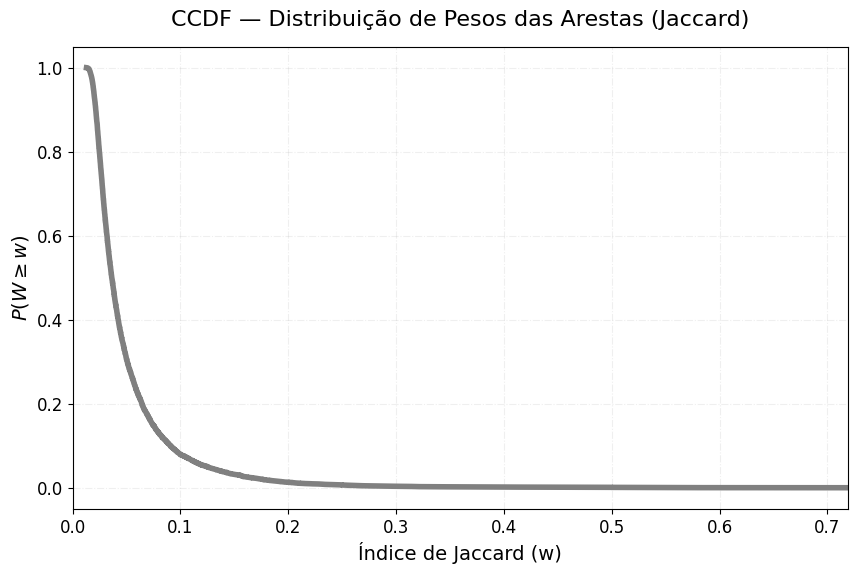

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# --- 1. Extrair os pesos de Jaccard das arestas ---
pesos_jaccard = [dados['peso_jaccard'] for u, v, dados in G.edges(data=True) if 'peso_jaccard' in dados]

if not pesos_jaccard:
    print("Erro: O atributo 'peso_jaccard' não foi encontrado nas arestas do grafo.")
else:
    # --- 2. Preparar os dados para a CCDF ---
    sorted_pesos = np.sort(pesos_jaccard)
    n = len(sorted_pesos)
    ccdf = 1.0 - (np.arange(n) / n)
    
    # Encontra o valor máximo real dos pesos para limitar o gráfico
    max_x = float(np.max(sorted_pesos))

    # --- 3. Plotagem Gráfica ---
    plt.figure(figsize=(10, 6), facecolor='white')

    plt.plot(sorted_pesos, ccdf, linewidth=4, color='gray', label='Índice de Jaccard')
    
    # --- LIMITANDO O EIXO X NO MÁXIMO REAL ---
    plt.xlim(0, max_x)
    
    # Formatação dos eixos e títulos
    plt.xlabel("Índice de Jaccard (w)", fontsize=14)
    plt.ylabel(r"$P(W \geq w)$", fontsize=14)
    plt.title("CCDF — Distribuição de Pesos das Arestas (Jaccard)", fontsize=16, pad=15)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.grid(True, which="both", linestyle="-.", alpha=0.2)
    plt.show()

In [ ]:
# 4. Salvar os resultados
    #OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    #df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8')
    
    #print('='*50)
    #print(f"Métricas salvas com sucesso em:\n{OUTPUT_CSV}")
    #print('='*50)